# Clean Data

In [17]:
#Cleaning Data
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load data
df = pd.read_csv('GlobalWeatherRepository.csv', on_bad_lines='skip')

# We only focus on thailand
df = df[df['location_name'] == 'Bangkok']
# Drop redundant data
# Using Celsius, km/h, mm
# Drop Fahrenheit, mph, inches and epoch time
cols_to_drop = [
    'temperature_fahrenheit',
    'wind_mph',
    'pressure_in',
    'precip_in',
    'feels_like_fahrenheit',
    'visibility_miles',
    'gust_mph',
    'last_updated_epoch',
    'country',
    'location_name',
    'timezone',
    'latitude',
    'longitude',
    'wind_degree',
    'wind_direction'
]
df = df.drop(columns=cols_to_drop)
# Drop complex time columns
complex_time_cols = ['sunrise', 'sunset', 'moonrise', 'moonset']
df = df.drop(columns=complex_time_cols)

# Datetime Features
# -------------------------
df['last_updated'] = pd.to_datetime(df['last_updated'], errors='coerce')
df['year'] = df['last_updated'].dt.year
df['month'] = df['last_updated'].dt.month
df['day'] = df['last_updated'].dt.day
df['hour'] = df['last_updated'].dt.hour
df = df.drop(columns=['last_updated'])

def simplify_condition(text):
    text = str(text).lower()

    if 'thunder' in text or 'storm' in text:
        return 'Thunder'
    elif 'drizzle' in text:
        return 'Drizzle'
    elif 'rain' in text:
        return 'Rain'
    elif 'cloud' in text or 'overcast' in text:
        return 'Cloudy'
    elif 'sunny' in text or 'clear' in text:
        return 'Clear'
    else:
        return 'Other'




df['condition_text'] = df['condition_text'].apply(simplify_condition)


# Categorical Data Handling
categorical_cols = ['condition_text','moon_phase']
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))



print(df['condition_text'].unique())


# Save
df.to_csv('Cleaned_Weather_Data.csv', index=False)

[1 4 3 0 2]


In [12]:
#Label mapping
import json
from sklearn.preprocessing import LabelEncoder

# 1. Load the dataset
df = pd.read_csv('GlobalWeatherRepository.csv', on_bad_lines='skip')

# 2. Define categorical columns to encode
categorical_cols = ['country', 'location_name', 'timezone', 'condition_text', 'wind_direction', 'moon_phase']

# Dictionary to store the mapping for each column
label_mappings = {}

# 3. Process each categorical column
for col in categorical_cols:
    le = LabelEncoder()
    # Fit and transform the data
    df[col] = le.fit_transform(df[col].astype(str))

    # Extract the mapping (index to class label)
    mapping = {int(index): label for index, label in enumerate(le.classes_)}

    # Store it in the main dictionary
    label_mappings[col] = mapping

# 4. Save the mappings to a JSON file
with open('label_mappings.json', 'w', encoding='utf-8') as file:
    json.dump(label_mappings, file, ensure_ascii=False, indent=4)

print("Dictionary saved successfully as 'label_mappings.json'")

# Display a sample of the mapping (top 5 countries)
print("\nSample mapping for top 5 countries:")
sample_countries = dict(list(label_mappings['country'].items())[:5])
print(sample_countries)

Dictionary saved successfully as 'label_mappings.json'

Sample mapping for top 5 countries:
{0: 'Afghanistan', 1: 'Albania', 2: 'Algeria', 3: 'Andorra', 4: 'Angola'}


In [18]:
#----------------------------
# EDA Setup (รันอันนี้ก่อน ไม่งั้นรันEDAกับFeatureไม่ได้)
#----------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

bangkok_df = pd.read_csv('Cleaned_Weather_Data.csv')

bangkok_df.info()
bangkok_df.describe()
bangkok_df.isnull().sum()

sns.set_style("whitegrid")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 696 entries, 0 to 695
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   temperature_celsius           696 non-null    float64
 1   condition_text                696 non-null    int64  
 2   wind_kph                      696 non-null    float64
 3   pressure_mb                   696 non-null    float64
 4   precip_mm                     696 non-null    float64
 5   humidity                      696 non-null    int64  
 6   cloud                         696 non-null    int64  
 7   feels_like_celsius            696 non-null    float64
 8   visibility_km                 696 non-null    float64
 9   uv_index                      696 non-null    float64
 10  gust_kph                      696 non-null    float64
 11  air_quality_Carbon_Monoxide   696 non-null    float64
 12  air_quality_Ozone             696 non-null    float64
 13  air_q

In [ ]:
bangkok_df.head(10)

,temperature_celsius,condition_text,wind_kph,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,visibility_km,uv_index,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_phase,moon_illumination,year,month,day,hour
0,31.0,1,15.1,1007.0,0.11,75,25,32.7,10.0,8.0,...,115.2,163.7,4,10,7,55,2024,5,16,15
1,30.0,1,11.2,1009.0,0.00,79,25,33.7,10.0,1.0,...,150.8,212.3,5,10,7,55,2024,5,16,21
2,31.0,1,9.0,1005.0,0.00,75,25,36.5,10.0,1.0,...,33.2,51.4,2,3,7,73,2024,5,18,21
3,27.0,4,9.0,1006.0,0.00,89,50,29.3,9.0,1.0,...,14.8,28.0,1,2,7,81,2024,5,19,21
4,30.0,1,6.1,1006.0,0.00,84,25,34.2,10.0,1.0,...,65.0,106.7,3,9,7,88,2024,5,20,21
5,27.0,3,3.6,1008.0,0.88,89,25,30.9,10.0,1.0,...,25.9,46.9,2,3,7,93,2024,5,21,21
6,30.0,1,9.0,1008.0,0.00,75,50,35.1,10.0,1.0,...,26.1,46.3,2,3,7,97,2024,5,22,21
7,27.0,3,6.8,1007.0,0.00,94,50,30.6,8.0,1.0,...,28.5,42.2,2,3,1,100,2024,5,23,21
8,30.0,1,13.0,1008.0,0.00,75,25,38.7,10.0,1.0,...,31.7,52.0,2,3,5,100,2024,5,24,21
9,30.0,1,6.1,1008.0,0.00,79,25,35.3,10.0,1.0,...,18.3,31.0,2,2,5,98,2024,5,25,21


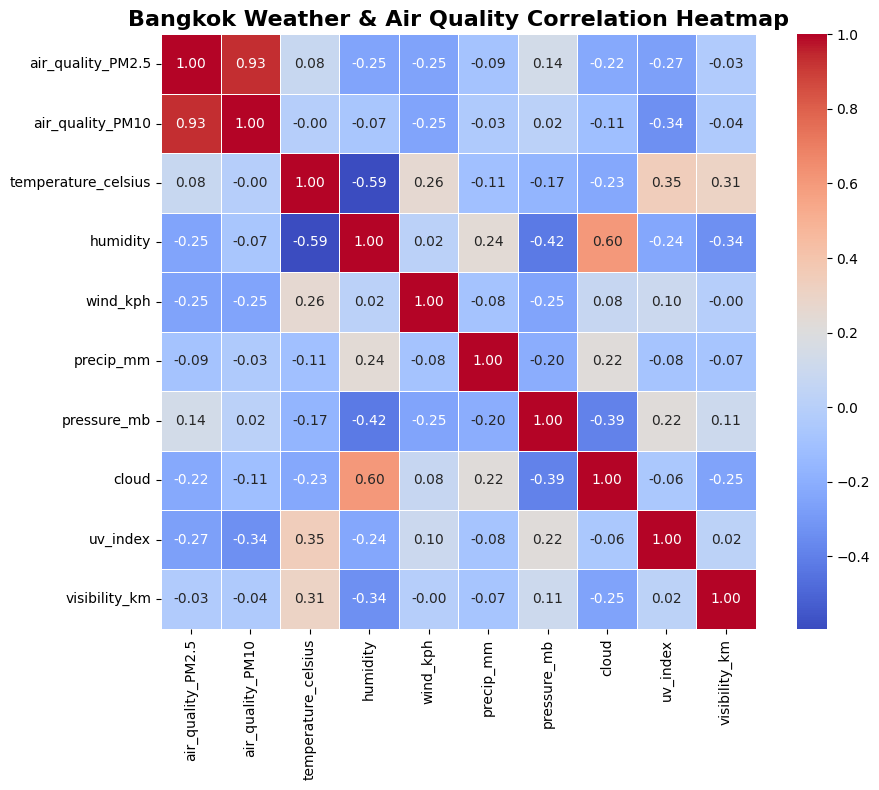

In [10]:
# Correlation Heatmap
cols = [
    'air_quality_PM2.5',
    'air_quality_PM10',
    'temperature_celsius',
    'humidity',
    'wind_kph',
    'precip_mm',
    'pressure_mb',
    'cloud',
    'uv_index',
    'visibility_km',
]
for col in cols:
    bangkok_df[col] = pd.to_numeric(bangkok_df[col])

bangkok_df = bangkok_df[cols].dropna()

corr = bangkok_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    square=True
)
plt.title("Bangkok Weather & Air Quality Correlation Heatmap",fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

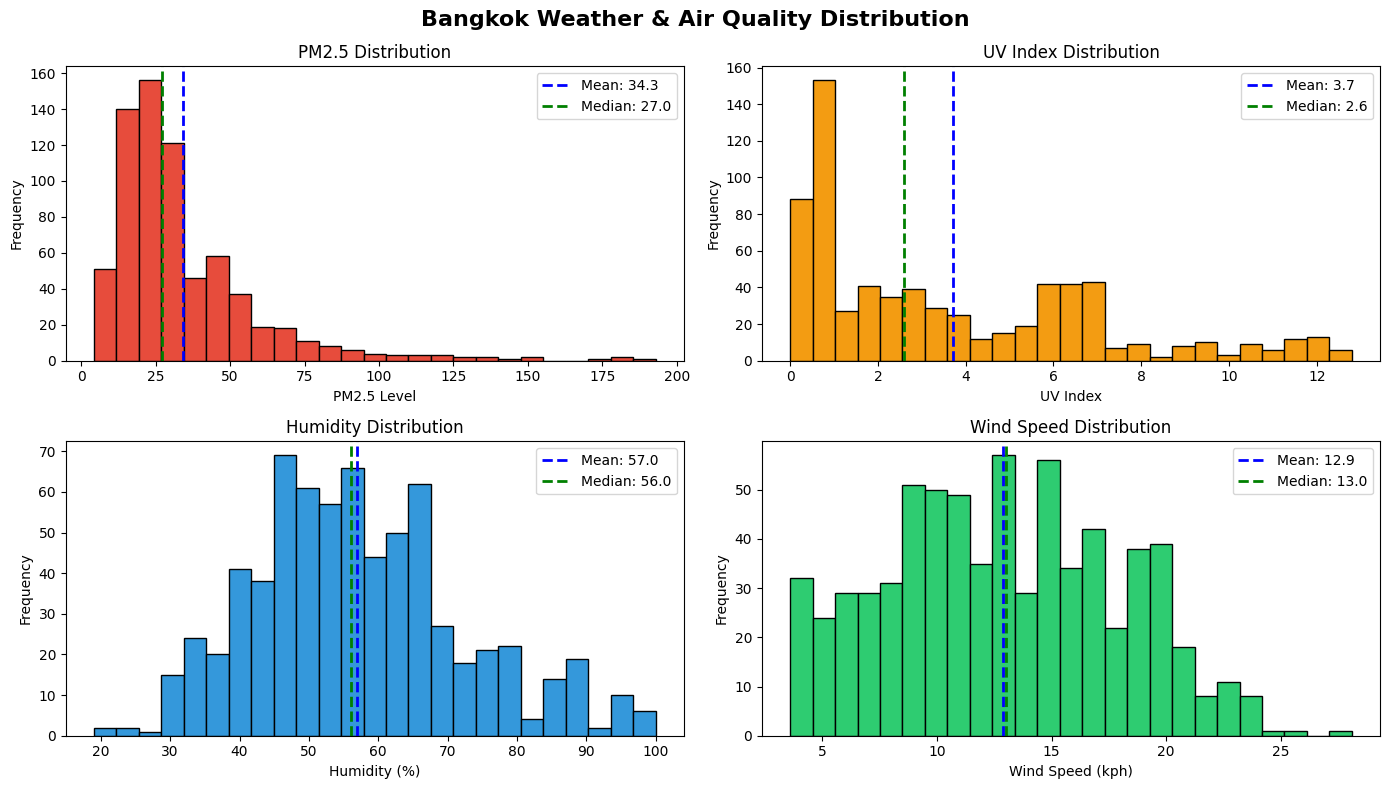

In [9]:
# Distribution
fig, axes = plt.subplots(2, 2, figsize=(14,8))
fig.suptitle("Bangkok Weather & Air Quality Distribution", fontsize=16, fontweight='bold')

cols = ['air_quality_PM2.5', 'uv_index', 'humidity', 'wind_kph']
for col in cols:
    bangkok_df[col] = pd.to_numeric(bangkok_df[col])

bangkok_df = bangkok_df.dropna()

# PM2.5
mean_pm = bangkok_df['air_quality_PM2.5'].mean()
median_pm = bangkok_df['air_quality_PM2.5'].median()

axes[0,0].hist(bangkok_df['air_quality_PM2.5'], bins=25, color='#e74c3c', edgecolor='black')
axes[0,0].axvline(mean_pm, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_pm:.1f}')
axes[0,0].axvline(median_pm, color='green', linestyle='--', linewidth=2, label=f'Median: {median_pm:.1f}')
axes[0,0].set_title("PM2.5 Distribution")
axes[0,0].set_xlabel("PM2.5 Level")
axes[0,0].set_ylabel("Frequency")
axes[0,0].legend()

# UV
mean_uv = bangkok_df['uv_index'].mean()
median_uv = bangkok_df['uv_index'].median()

axes[0,1].hist(bangkok_df['uv_index'], bins=25, color='#f39c12', edgecolor='black')
axes[0,1].axvline(mean_uv, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_uv:.1f}')
axes[0,1].axvline(median_uv, color='green', linestyle='--', linewidth=2, label=f'Median: {median_uv:.1f}')
axes[0,1].set_title("UV Index Distribution")
axes[0,1].set_xlabel("UV Index")
axes[0,1].set_ylabel("Frequency")
axes[0,1].legend()

# Humidity
mean_h = bangkok_df['humidity'].mean()
median_h = bangkok_df['humidity'].median()

axes[1,0].hist(bangkok_df['humidity'], bins=25, color='#3498db', edgecolor='black')
axes[1,0].axvline(mean_h, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_h:.1f}')
axes[1,0].axvline(median_h, color='green', linestyle='--', linewidth=2, label=f'Median: {median_h:.1f}')
axes[1,0].set_title("Humidity Distribution")
axes[1,0].set_xlabel("Humidity (%)")
axes[1,0].set_ylabel("Frequency")
axes[1,0].legend()

# Wind Speed
mean_w = bangkok_df['wind_kph'].mean()
median_w = bangkok_df['wind_kph'].median()

axes[1,1].hist(bangkok_df['wind_kph'], bins=25, color='#2ecc71', edgecolor='black')
axes[1,1].axvline(mean_w, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_w:.1f}')
axes[1,1].axvline(median_w, color='green', linestyle='--', linewidth=2, label=f'Median: {median_w:.1f}')
axes[1,1].set_title("Wind Speed Distribution")
axes[1,1].set_xlabel("Wind Speed (kph)")
axes[1,1].set_ylabel("Frequency")
axes[1,1].legend()

plt.tight_layout()
plt.show()

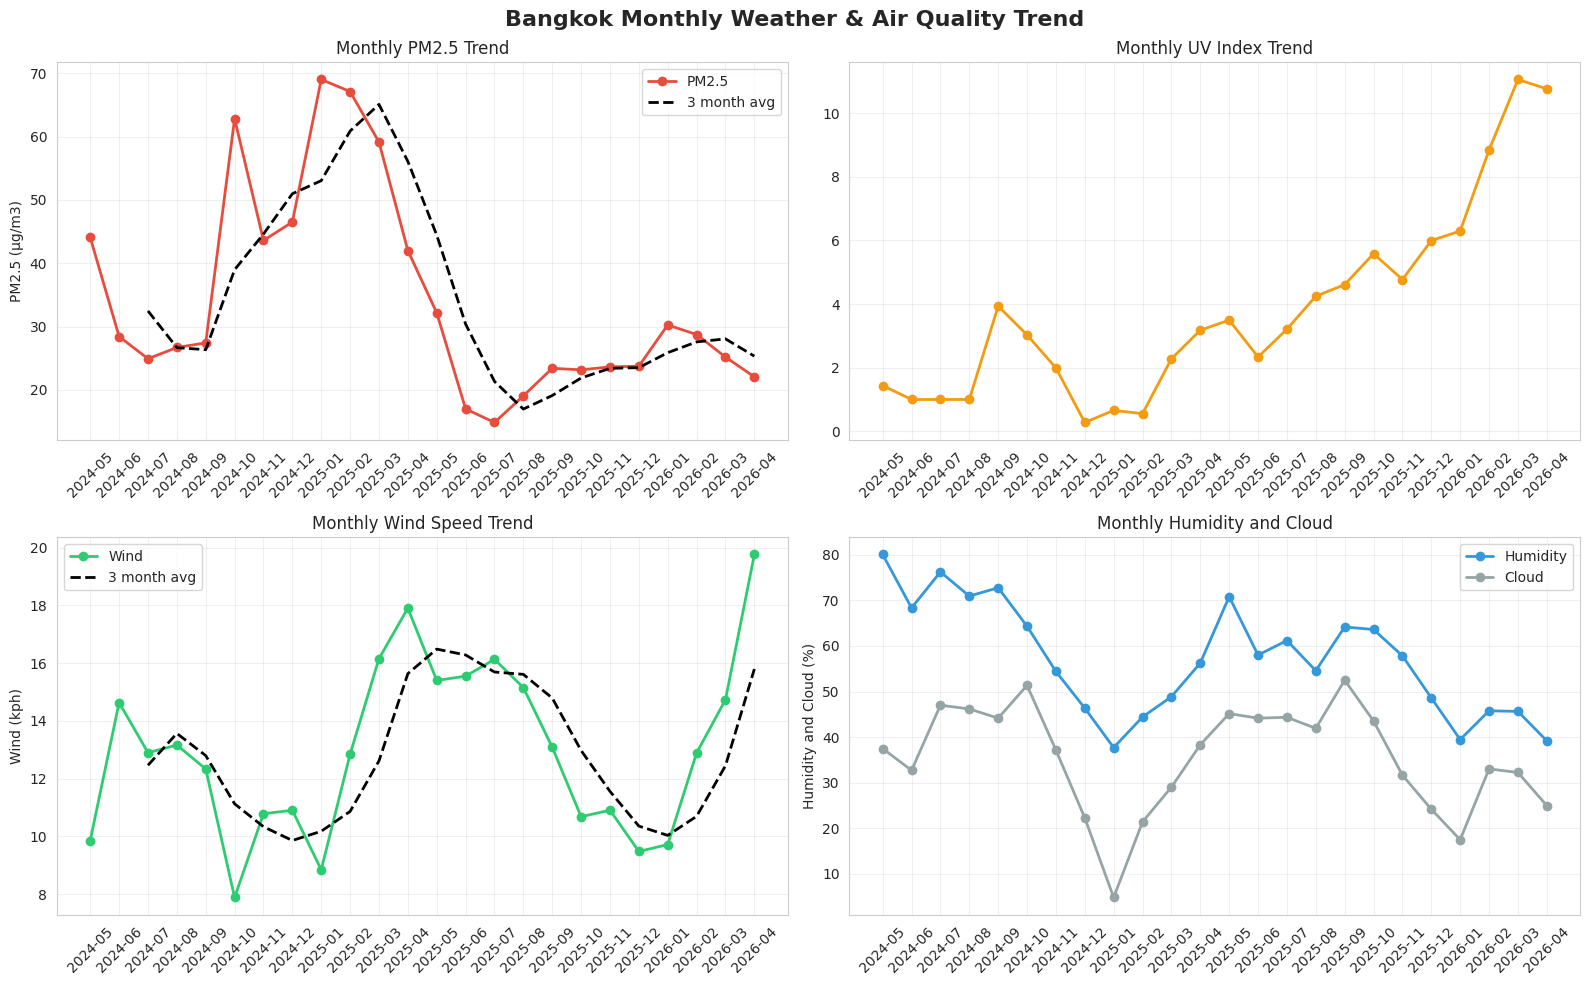

In [ ]:
# Monthly Trend
fig, axes = plt.subplots(2,2, figsize=(16,10))
fig.suptitle("Bangkok Monthly Weather & Air Quality Trend", fontsize=16, fontweight='bold')

cols = ['air_quality_PM2.5', 'uv_index', 'wind_kph', 'humidity', 'cloud']
for col in cols:
    bangkok_df[col] = pd.to_numeric(bangkok_df[col])

bangkok_df = bangkok_df.dropna()
bangkok_df['year_month'] = (
    bangkok_df['year'].astype(int).astype(str) + '-' +
    bangkok_df['month'].astype(int).astype(str).str.zfill(2)
)
# monthly avg
monthly = bangkok_df.groupby('year_month')[cols].mean().reset_index()

# 3 month avg
monthly['pm_mavg3'] = monthly['air_quality_PM2.5'].rolling(3).mean()
monthly['wind_mavg3'] = monthly['wind_kph'].rolling(3).mean()

# PM2.5
axes[0,0].plot(monthly['year_month'], monthly['air_quality_PM2.5'],
               color='#e74c3c', marker='o', linewidth=2, label='PM2.5')
axes[0,0].plot(monthly['year_month'], monthly['pm_mavg3'],
               color='black', linestyle='--', linewidth=2, label='3 month avg')
axes[0,0].set_title("Monthly PM2.5 Trend")
axes[0,0].set_ylabel("PM2.5 (µg/m3)")
axes[0,0].legend()

# UV Index
axes[0,1].plot(monthly['year_month'], monthly['uv_index'],
               color='#f39c12', marker='o', linewidth=2)
axes[0,1].set_title("Monthly UV Index Trend")

# Wind
axes[1,0].plot(monthly['year_month'], monthly['wind_kph'],
               color='#2ecc71', marker='o', linewidth=2, label='Wind')
axes[1,0].plot(monthly['year_month'], monthly['wind_mavg3'],
               color='black', linestyle='--', linewidth=2, label='3 month avg')
axes[1,0].set_title("Monthly Wind Speed Trend")
axes[1,0].set_ylabel("Wind (kph)")
axes[1,0].legend()

# Humidity and Cloud
ax1 = axes[1,1]
ax2 = axes[1,1]

ax1.plot(monthly['year_month'], monthly['humidity'],
         color='#3498db', marker='o', linewidth=2, label='Humidity')

ax2.plot(monthly['year_month'], monthly['cloud'],
         color='#95a5a6', marker='o', linewidth=2, label='Cloud')

ax1.set_title("Monthly Humidity and Cloud")
ax1.set_ylabel("Humidity and Cloud (%)")
ax1.legend()

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

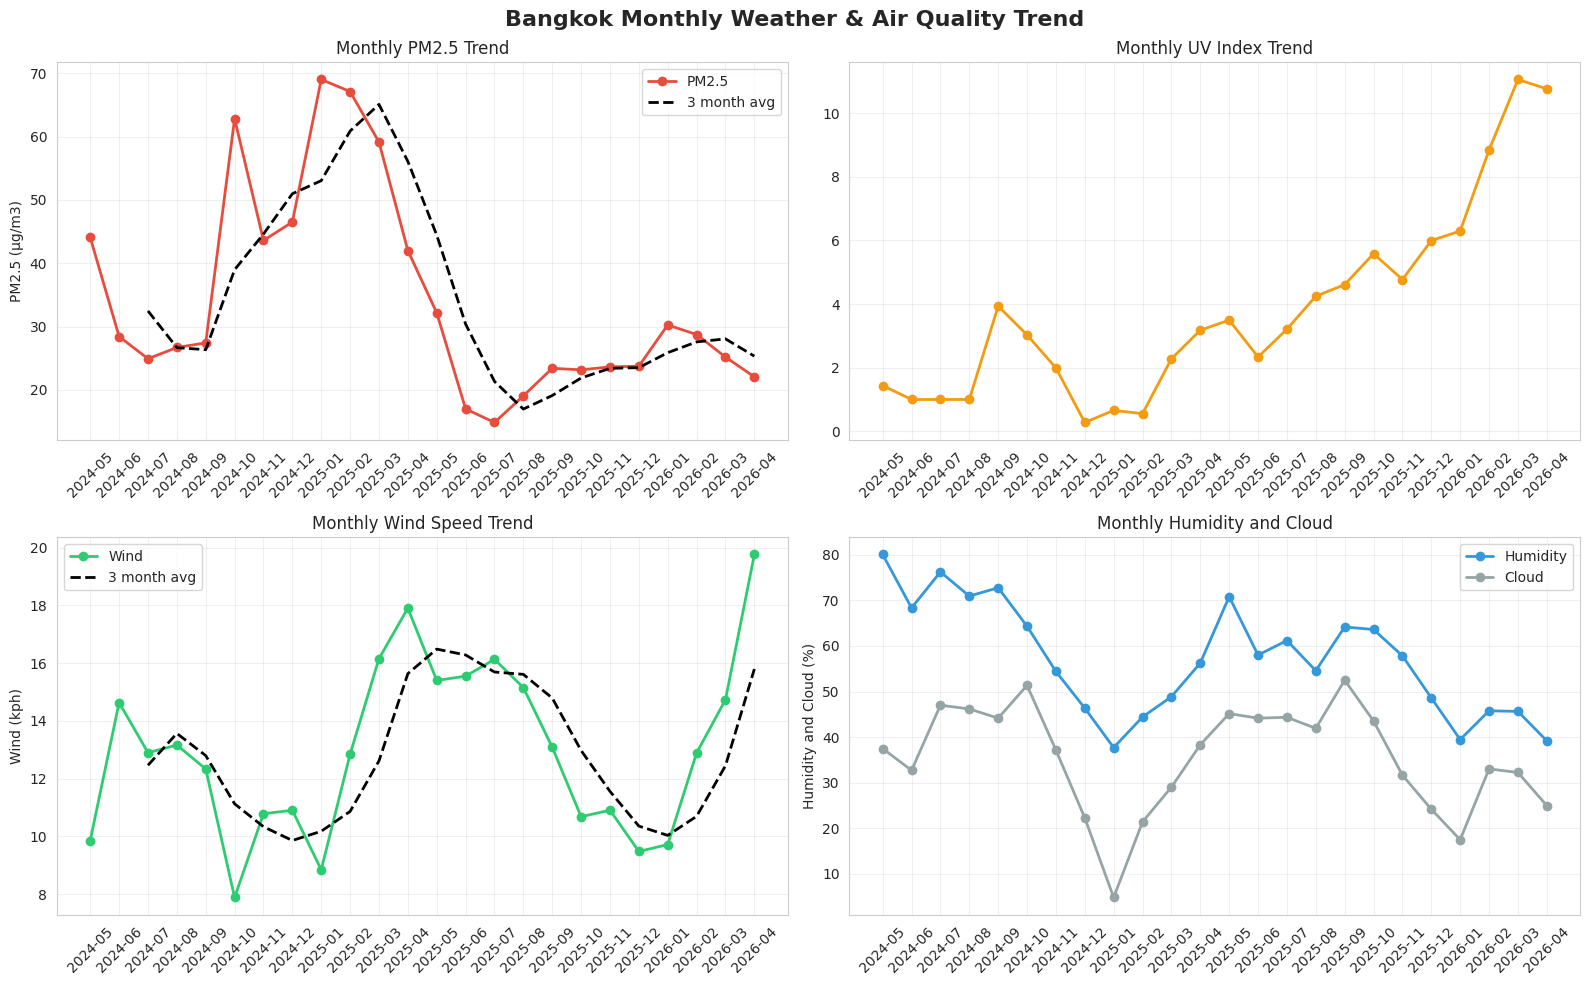

In [ ]:
# Monthly Trend
fig, axes = plt.subplots(2,2, figsize=(16,10))
fig.suptitle("Bangkok Monthly Weather & Air Quality Trend", fontsize=16, fontweight='bold')

cols = ['air_quality_PM2.5', 'uv_index', 'wind_kph', 'humidity', 'cloud']
for col in cols:
    bangkok_df[col] = pd.to_numeric(bangkok_df[col])

bangkok_df = bangkok_df.dropna()
bangkok_df['year_month'] = (
    bangkok_df['year'].astype(int).astype(str) + '-' +
    bangkok_df['month'].astype(int).astype(str).str.zfill(2)
)
# monthly avg
monthly = bangkok_df.groupby('year_month')[cols].mean().reset_index()

# 3 month avg
monthly['pm_mavg3'] = monthly['air_quality_PM2.5'].rolling(3).mean()
monthly['wind_mavg3'] = monthly['wind_kph'].rolling(3).mean()

# PM2.5
axes[0,0].plot(monthly['year_month'], monthly['air_quality_PM2.5'],
               color='#e74c3c', marker='o', linewidth=2, label='PM2.5')
axes[0,0].plot(monthly['year_month'], monthly['pm_mavg3'],
               color='black', linestyle='--', linewidth=2, label='3 month avg')
axes[0,0].set_title("Monthly PM2.5 Trend")
axes[0,0].set_ylabel("PM2.5 (µg/m3)")
axes[0,0].legend()

# UV Index
axes[0,1].plot(monthly['year_month'], monthly['uv_index'],
               color='#f39c12', marker='o', linewidth=2)
axes[0,1].set_title("Monthly UV Index Trend")

# Wind
axes[1,0].plot(monthly['year_month'], monthly['wind_kph'],
               color='#2ecc71', marker='o', linewidth=2, label='Wind')
axes[1,0].plot(monthly['year_month'], monthly['wind_mavg3'],
               color='black', linestyle='--', linewidth=2, label='3 month avg')
axes[1,0].set_title("Monthly Wind Speed Trend")
axes[1,0].set_ylabel("Wind (kph)")
axes[1,0].legend()

# Humidity and Cloud
ax1 = axes[1,1]
ax2 = axes[1,1]

ax1.plot(monthly['year_month'], monthly['humidity'],
         color='#3498db', marker='o', linewidth=2, label='Humidity')

ax2.plot(monthly['year_month'], monthly['cloud'],
         color='#95a5a6', marker='o', linewidth=2, label='Cloud')

ax1.set_title("Monthly Humidity and Cloud")
ax1.set_ylabel("Humidity and Cloud (%)")
ax1.legend()

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

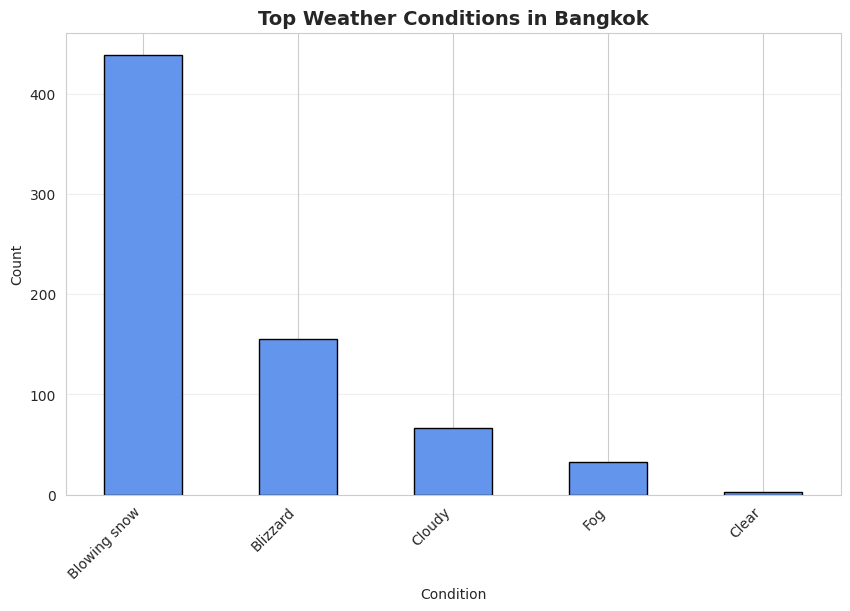

In [30]:
#ยังไม่ต้องสนใจ
#with open('label_mappings.json', 'r', encoding='utf-8') as f:
#    mappings = json.load(f)

#condition_map = mappings['condition_text']

#top_cond = bangkok_df['condition_text'].value_counts().head(10)
#top_cond.index = top_cond.index.map(lambda x: condition_map[str(x)])
#top_cond.plot(kind='bar', figsize=(10,6), color='cornflowerblue', edgecolor='black')

#plt.title("Top Weather Conditions in Bangkok", fontsize=14, fontweight='bold')
#plt.xlabel("Condition")
#plt.ylabel("Count")
#plt.xticks(rotation=45, ha='right')
#plt.grid(axis='y', alpha=0.3)
#plt.show()

In [ ]:
#----------------------------
# Feature Engineering
#----------------------------

# Season from month
def get_season(month):
    if month in [11, 12, 1, 2]:
        return "Cool"
    elif month in [3, 4, 5]:
        return "Hot"
    else:
        return "Rainy"

bangkok_df['season'] = bangkok_df['month'].apply(get_season)
bangkok_df['quarter'] = ((bangkok_df['month'] - 1) // 3) + 1

bangkok_df[['month', 'season', 'quarter']].sample(10)

,month,season,quarter
693,4,Hot,2
168,11,Cool,4
429,7,Rainy,3
439,8,Rainy,3
78,8,Rainy,3
440,8,Rainy,3
138,10,Rainy,4
307,3,Hot,1
277,2,Cool,1
632,2,Cool,1


In [ ]:
# Lag 1 day
bangkok_df['pm_lag'] = bangkok_df['air_quality_PM2.5'].shift(1)
bangkok_df['wind_lag'] = bangkok_df['wind_kph'].shift(1)
bangkok_df['humidity_lag'] = bangkok_df['humidity'].shift(1)
bangkok_df['temp_lag'] = bangkok_df['temperature_celsius'].shift(1)

bangkok_df[['air_quality_PM2.5','pm_lag',
            'wind_kph','wind_lag',
            'humidity','humidity_lag',
            'temperature_celsius','temp_lag']].head(10)

,air_quality_PM2.5,pm_lag,wind_kph,wind_lag,humidity,humidity_lag,temperature_celsius,temp_lag
0,115.2,NaN,15.1,NaN,75,NaN,31.0,NaN
1,150.8,115.2,11.2,15.1,79,75.0,30.0,31.0
2,33.2,150.8,9.0,11.2,75,79.0,31.0,30.0
3,14.8,33.2,9.0,9.0,89,75.0,27.0,31.0
4,65.0,14.8,6.1,9.0,84,89.0,30.0,27.0
5,25.9,65.0,3.6,6.1,89,84.0,27.0,30.0
6,26.1,25.9,9.0,3.6,75,89.0,30.0,27.0
7,28.5,26.1,6.8,9.0,94,75.0,27.0,30.0
8,31.7,28.5,13.0,6.8,75,94.0,30.0,27.0
9,18.3,31.7,6.1,13.0,79,75.0,30.0,30.0


In [ ]:
# Interaction
bangkok_df['Humidity_over_Cloud'] = bangkok_df['humidity'] / bangkok_df['cloud']
bangkok_df['Humidity_over_Temp'] = bangkok_df['humidity'] / bangkok_df['temperature_celsius']
bangkok_df['Humidity_over_Visibility'] = bangkok_df['humidity'] / bangkok_df['visibility_km']
bangkok_df['Gust_over_Wind'] = bangkok_df['gust_kph'] / bangkok_df['wind_kph']
bangkok_df[[ 'temperature_celsius',
           'humidity',
           'visibility_km',
           'cloud',
           'gust_kph',
           'wind_kph',
           'Humidity_over_Cloud',
           'Humidity_over_Temp',
           'Humidity_over_Visibility',
           'Gust_over_Wind']].head(10)

,temperature_celsius,humidity,visibility_km,cloud,gust_kph,wind_kph,Humidity_over_Cloud,Humidity_over_Temp,Humidity_over_Visibility,Gust_over_Wind
0,31.0,75,10.0,25,18.2,15.1,3.00,2.419355,7.500000,1.205298
1,30.0,79,10.0,25,20.9,11.2,3.16,2.633333,7.900000,1.866071
2,31.0,75,10.0,25,24.1,9.0,3.00,2.419355,7.500000,2.677778
3,27.0,89,9.0,50,23.2,9.0,1.78,3.296296,9.888889,2.577778
4,30.0,84,10.0,25,24.8,6.1,3.36,2.800000,8.400000,4.065574
5,27.0,89,10.0,25,37.5,3.6,3.56,3.296296,8.900000,10.416667
6,30.0,75,10.0,50,17.0,9.0,1.50,2.500000,7.500000,1.888889
7,27.0,94,8.0,50,14.6,6.8,1.88,3.481481,11.750000,2.147059
8,30.0,75,10.0,25,20.2,13.0,3.00,2.500000,7.500000,1.553846
9,30.0,79,10.0,25,13.1,6.1,3.16,2.633333,7.900000,2.147541


In [ ]:
# Day/Night
bangkok_df['is_day'] = bangkok_df['hour'].apply(lambda x: 1 if 6 <= x <= 18 else 0)
bangkok_df[['hour',
           'is_day']].sample(10)

,hour,is_day
681,13,1
631,15,1
149,16,1
309,16,1
34,21,0
380,16,1
301,16,1
353,15,1
679,13,1
147,16,1
